<a href="https://colab.research.google.com/github/ravitkurakula/RaviGPT/blob/main/RaviGPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import torch
import torch.nn as nn

In [60]:
with open("/content/drive/MyDrive/RaviGPT/data/tiny-shakespeare.txt", 'r', encoding = "utf-8") as f :
  text = f.read()

  print(len(text))
  print(text[:500])

1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [61]:
class CharTokenizer :
  def __init__(self,text) :
    self.char = sorted(list(set(text)))
    self.stoi = {ch : i for i,ch in enumerate(self.char)}
    self.itos = {i : ch for i,ch in enumerate(self.char)}

  @property
  def vocab_size(self):
    return len(self.char)

  def encode(self,text) :
    return [self.stoi[ch] for ch in text]

  def decode(self,tokens):
    return ''.join(self.itos[token] for token in tokens)

In [62]:
tokenizer = CharTokenizer(text)

In [63]:
class TextDataset :
  def __init__(self,data,block_size):
    self.data = data
    self.block_size = block_size

  def __len__(self):
    return len(self.data) - self.block_size

  def __getitem__(self,idx):
    x = self.data[idx : idx+self.block_size]
    y = self.data[idx+1 : idx+self.block_size+1]

    return x,y

In [64]:
data = tokenizer.encode(text)
dataset = TextDataset(data,block_size=64)


In [65]:
block_size = 64
batch_size = 32
d_model = 128
n_heads = 4
n_layers = 4
dropout = 0.1

vocab_size  = tokenizer.vocab_size

In [66]:
n = int(0.9 *len(data))

train_data = torch.tensor(data[:n],dtype= torch.long)
val_data = torch.tensor(data[n:],dtype=torch.long)
print("Total : ", len(data))
print("Train", len(train_data))
print("Validation : ", len(val_data))

Total :  1115394
Train 1003854
Validation :  111540


In [67]:
def get_batch(split,batch_size=32,block_size=64):
  data = train_data if split == "train" else val_data

  ix =  torch.randint(len(data)-block_size, (batch_size,))
  x=  torch.stack([data[i:i + block_size] for i in ix])
  y = torch.stack([data[i+1 : i +block_size+1] for i in ix])

  return x,y

In [68]:
x,y = get_batch("train")

print(x.shape)
print(y.shape)

torch.Size([32, 64])
torch.Size([32, 64])


In [69]:
mask = torch.tril(torch.ones(4,4))

In [70]:
class MultiHeadAttention(nn.Module):
  def __init__(self,d_model,num_heads):
    super().__init__()

    self.d_model = d_model
    self.num_heads = num_heads
    self.head_dim = d_model // num_heads

    self.W_Q = nn.Linear(d_model,d_model)
    self.W_K = nn.Linear(d_model,d_model)
    self.W_V = nn.Linear(d_model,d_model)

    self.out_proj  = nn.Linear(d_model,d_model)

  def forward(self,x,mask):
    B,T,C = x.shape

    q = self.W_Q(x)
    k = self.W_K(x)
    v = self.W_V(x)

    q= q.view(B,T,self.num_heads,self.head_dim)
    k= k.view(B,T,self.num_heads,self.head_dim)
    v= v.view(B,T,self.num_heads,self.head_dim)

    q= q.transpose(1,2)
    k= k.transpose(1,2)
    v= v.transpose(1,2)

    scores = q@k.transpose(-2,-1)
    scores = scores/(self.head_dim**0.5)

    scores = scores.masked_fill(mask == 0, float('-inf'))
    attention_weights = torch.softmax(scores,dim=-1)
    output = attention_weights@v

    output = output.transpose(1,2)
    output = output.contiguous().view(B,T,self.d_model)

    output = self.out_proj(output)

    return output

In [71]:
d_model =128
num_heads =4
attention = MultiHeadAttention(d_model,num_heads)
x,y = get_batch("train",batch_size= 32, block_size=64)
mask = torch.tril(torch.ones(64,64))
embedding = nn.Embedding(tokenizer.vocab_size,d_model)
x_embedding = embedding(x)
output = attention(x_embedding,mask)

In [72]:
class TransformerBlock(nn.Module):
  def __init__(self,d_model,num_heads,d_ff):
    super().__init__()

    self.ln1 = nn.LayerNorm(d_model)
    self.attention = MultiHeadAttention(d_model,num_heads)
    self.ln2 = nn.LayerNorm(d_model)

    self.fc1 = nn.Linear(d_model,d_ff)
    self.fc2 = nn.Linear(d_ff,d_model)

  def forward(self,x,mask) :
      normalized_x = self.ln1(x)
      attention_output = self.attention(normalized_x,mask)
      x= x + attention_output
      normalized_x = self.ln2(x)

      hidden = self.fc1(normalized_x)
      hidden = torch.nn.functional.gelu(hidden)

      mlp_output = self.fc2(hidden)

      x = x + mlp_output

      return x


In [73]:
block = TransformerBlock(d_model = 128, num_heads = 4, d_ff = 512)

output = block(x_embedding,mask)

In [74]:
class TransformersStack(nn.Module):
  def __init__(self,num_blocks,d_model,num_heads,d_ff):
    super().__init__()

    self.blocks = nn.ModuleList([
        TransformerBlock(d_model,num_heads,d_ff) for _ in range(num_blocks)
    ])

  def forward(self,x,mask):
    for block in self.blocks:
      x = block(x,mask)
    return x

In [75]:
stack = TransformersStack(
    num_blocks = 4,
    d_model = 128,
    num_heads = 4,
    d_ff =512
)
output = stack(x_embedding,mask)


In [76]:
final_ln = nn.LayerNorm(d_model)


In [77]:
output = final_ln(output)

In [78]:
lm_head = nn.Linear(d_model,vocab_size)
logits = lm_head(output)

In [79]:
print("Stack output : ", output.shape)
print("Logits :", logits.shape)

Stack output :  torch.Size([32, 64, 128])
Logits : torch.Size([32, 64, 65])


In [80]:
class TransformerLanguageModel(nn.Module):
  def __init__(self,vocab_size,d_model,num_heads,d_ff,num_blocks,block_size):
    super().__init__()
    self.token_embedding = nn.Embedding(vocab_size,d_model)
    self.position_embedding = nn.Embedding(block_size,d_model)
    self.stack = TransformersStack(
        num_blocks,
        d_model,
        num_heads,
        d_ff
    )
    self.final_ln = nn.LayerNorm(d_model)
    self.lm_head = nn.Linear(d_model,vocab_size)

  def forward(self,x,mask):
    B,T = x.shape

    positions = torch.arange(T,device = x.device)
    token_emb = self.token_embedding(x)
    position_emb = self.position_embedding(positions)

    x = token_emb+position_emb
    x= self.stack(x,mask)
    x = self.final_ln(x)
    logits = self.lm_head(x)

    return logits

In [81]:
vocab_size = tokenizer.vocab_size
d_model = 128
num_heads= 4
d_ff = 512
num_blocks = 4
block_size = 64

In [82]:
model  = TransformerLanguageModel(
    vocab_size,
    d_model,
    num_heads,
    d_ff,
    num_blocks,
    block_size
)

In [83]:
logits  = model(x,mask)


In [84]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr= 3e-4
)

In [85]:
@torch.no_grad()
def estimate_loss():
    model.eval()

    losses = {}

    for split in ["train", "val"]:
        split_losses = []

        for _ in range(10):
            x, y = get_batch(split)

            logits = model(x, mask)

            B, T, V = logits.shape

            logits = logits.view(B * T, V)
            y = y.view(B * T)

            loss = F.cross_entropy(logits, y)

            split_losses.append(loss.item())

        losses[split] = sum(split_losses) / len(split_losses)

    model.train()

    return losses

In [86]:
import torch.nn.functional as F

train_losses = []
val_losses = []

for step in range(10000):

    # ----------------
    # Training
    # ----------------
    x, y = get_batch("train")

    logits = model(x, mask)

    B, T, V = logits.shape

    logits = logits.view(B * T, V)
    y = y.view(B * T)

    loss = F.cross_entropy(logits, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    # ----------------
    # Evaluation
    # ----------------
    if step % 100 == 0:

        losses = estimate_loss()

        train_losses.append(losses["train"])
        val_losses.append(losses["val"])

        print(
            f"Step {step}: "
            f"train loss {losses['train']:.4f}, "
            f"val loss {losses['val']:.4f}"
        )

Step 0: train loss 4.2169, val loss 4.2080
Step 100: train loss 2.6412, val loss 2.6829
Step 200: train loss 2.4911, val loss 2.5002
Step 300: train loss 2.4290, val loss 2.4447
Step 400: train loss 2.3137, val loss 2.3442
Step 500: train loss 2.2317, val loss 2.2584
Step 600: train loss 2.1669, val loss 2.2120
Step 700: train loss 2.1381, val loss 2.1520
Step 800: train loss 2.0697, val loss 2.1157
Step 900: train loss 2.0132, val loss 2.0856
Step 1000: train loss 1.9651, val loss 2.0335
Step 1100: train loss 1.9329, val loss 2.0047
Step 1200: train loss 1.9013, val loss 2.0332
Step 1300: train loss 1.9023, val loss 1.9680
Step 1400: train loss 1.8434, val loss 1.9535
Step 1500: train loss 1.8453, val loss 1.9576
Step 1600: train loss 1.8220, val loss 1.9390
Step 1700: train loss 1.7764, val loss 1.9155
Step 1800: train loss 1.7858, val loss 1.8990
Step 1900: train loss 1.7465, val loss 1.9149
Step 2000: train loss 1.7347, val loss 1.8760
Step 2100: train loss 1.7242, val loss 1.8560


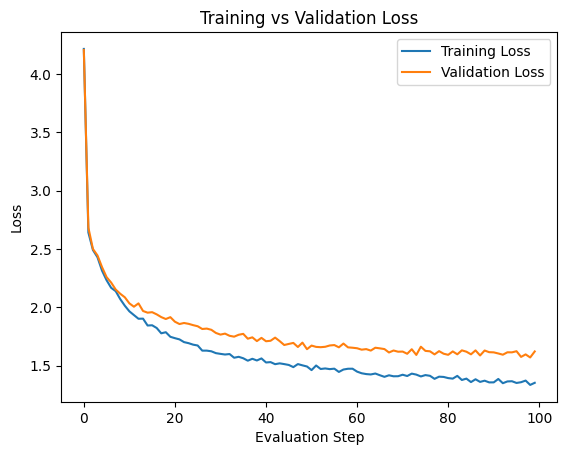

In [87]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()